In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
uciml_sms_spam_collection_dataset_path = kagglehub.dataset_download('uciml/sms-spam-collection-dataset')

print('Data source import complete.')


# NLP Preprocessing and Text Classification

###    **Name:** [Pranay Karmankar]  
###   **PRN:** [202301100014]  

---

### **Project Resources**
* **Dataset:** [SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)
* **GitHub Repository:** [Github](https://github.com/Pranaykarmankar/nlp-preprocessing-and-text-classification.git)
* **Kaggle Notebook:** [Kaggle](https://www.kaggle.com/code/pranay0/notebook9e179f29da)

# # Step 1: Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import kagglehub
import os
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Step 1: Import Libraries and Load Data ---
# Download essential NLTK components
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Download latest version of the dataset
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
print("Path to dataset files:", path)

# Locate the spam.csv file in the downloaded path
csv_path = os.path.join(path, "spam.csv")

# Load the dataset (handling the common latin-1 encoding for this file)
try:
    df = pd.read_csv(csv_path, encoding='latin-1')
except:
    df = pd.read_csv(csv_path, encoding='utf-8')

# Basic Cleaning: Drop unnecessary columns and rename
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df.columns = ['label', 'message']

# Encode labels: ham -> 0, spam -> 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
print("\nDataset Head:")
display(df.head())

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Path to dataset files: /kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset

Dataset Head:


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


# Step 2: NLP Preprocessing Pipeline

In [ ]:
# Initialize Stemmer and Lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text, method='lemmatize'):
    # A. Tokenization & Lowercasing
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())

    # B. Tokenization
    words = nltk.word_tokenize(text)

    # C. Stopword Removal & Transformation
    if method == 'stem':
        # Stemming (Chops words like 'running' to 'run')
        cleaned = [stemmer.stem(w) for w in words if w not in stop_words]
    else:
        # Lemmatization (Converts 'better' to 'good' using dictionary root)
        cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(cleaned)

# Apply preprocessing
df['processed_msg'] = df['message'].apply(lambda x: clean_text(x, method='lemmatize'))
print("\nPreprocessed Messages:")
print(df[['message', 'processed_msg']].head())


Preprocessed Messages:
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       processed_msg  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4                nah think go usf life around though  


# Step 3: Text Vectorization

In [ ]:
# Define Features and Target
X = df['processed_msg']
y = df['label_num']

# 1. CountVectorizer (Binary counts)
cv = CountVectorizer(max_features=2500)
X_cv = cv.fit_transform(X)

# 2. TF-IDF (Weighted importance)
tfidf = TfidfVectorizer(max_features=2500)
X_tfidf = tfidf.fit_transform(X)

print(f"\nCountVectorizer Shape: {X_cv.shape}")
print(f"TF-IDF Shape: {X_tfidf.shape}")


CountVectorizer Shape: (5572, 2500)
TF-IDF Shape: (5572, 2500)


# Step 4: Model Building & Evaluation


--- MODEL PERFORMANCE ---
Accuracy Score: 0.9785

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.85      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



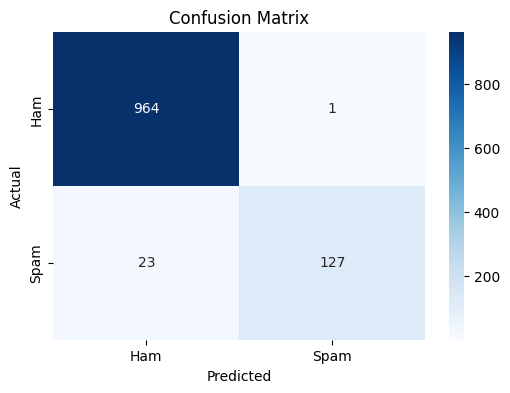

In [ ]:
# Split the TF-IDF data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Build Model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\n--- MODEL PERFORMANCE ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plotting Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 5: Testing with a Sample Message

In [ ]:
def predict_spam(sample_message):
    processed = clean_text(sample_message)
    vectorized = tfidf.transform([processed])
    prediction = model.predict(vectorized)
    return "SPAM" if prediction[0] == 1 else "HAM"

# Test samples
print(f"Test 1: 'Hey, are you coming for dinner tonight?' -> {predict_spam('Hey, are you coming for dinner tonight?')}")

Test 1: 'Hey, are you coming for dinner tonight?' -> HAM
